## Phase 4: Stock-Out Prediction Model — Summary

Two models were trained to predict `StockoutNext7Days`, using a time-based 80/20
train/test split (not random) to reflect realistic forecasting conditions.

**Logistic Regression (baseline):** ROC-AUC 0.844, recall 81%, precision 2% for the
stock-out class. Required feature scaling (StandardScaler) to converge — unscaled
features caused the solver to fail to converge even on a small sample.

**XGBoost:** ROC-AUC 0.959, recall 83%, precision 11% for the stock-out class — a
clear improvement over the baseline, catching a similar share of actual stock-outs
while raising far fewer false alarms.

**Data leakage found and fixed:** `StoreTypeStockoutRate` was originally calculated
using the full dataset (including the test period), which meant the model could
indirectly "see" future information during training. This was fixed by recalculating
the rate using only training-period data, then applying those values to the full
dataset (the same approach used for feature scaling). Interestingly, the fix changed
results only marginally (ROC-AUC 0.958 → 0.959), since store type has only 4 categories
across hundreds of thousands of rows — the leaky and clean estimates converged to
nearly the same values in practice. This is noted as a methodological correction made
for rigor, even though its real-world impact on this particular dataset was small.

Both `Sales`, `Customers`, `SalesRatio`, and `LikelyStockout` were excluded from the
feature set entirely, since they were derived from same-day information used to build
the target itself.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Stock_Out_Prediction/train_features.csv', dtype={'StateHoliday': str})
df.shape

(1017209, 29)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
leakage_cols = ['SalesRatio', 'LikelyStockout', 'Sales', 'Customers']
categorical_cols = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']
id_cols = ['Store', 'Date']
target_col = 'StockoutNext7Days'
feature_cols = [c for c in df.columns if c not in leakage_cols + categorical_cols + id_cols + [target_col]]
print(feature_cols)


['DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'SalesVelocity7', 'SalesVelocity14', 'SalesTrend', 'Month', 'IsWeekend', 'DaysSinceLastVisit', 'CompetitionOpen', 'StoreTypeStockoutRate']


In [6]:
split_date = df['Date'].quantile(0.8, interpolation='nearest')
train_stockout_rate_by_type = df[df['Date'] <= split_date].groupby('StoreType')['LikelyStockout'].mean()
df['StoreTypeStockoutRate'] = df['StoreType'].map(train_stockout_rate_by_type)
df['StoreTypeStockoutRate'] = df['StoreTypeStockoutRate'].fillna(train_stockout_rate_by_type.mean())

In [7]:
train_stockout_rate_by_type = df[df['Date'] <= split_date].groupby('StoreType')['LikelyStockout'].mean()
print(train_stockout_rate_by_type)

StoreType
a    0.002018
b    0.000785
c    0.000337
d    0.000309
Name: LikelyStockout, dtype: float64


In [8]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
feature_cols_final = feature_cols + [c for c in df_encoded.columns if any(c.startswith(cat + '_') for cat in categorical_cols)]
print(len(feature_cols_final), 'features')



29 features


In [9]:
split_date = df['Date'].quantile(0.8, interpolation='nearest')
train_df = df_encoded[df_encoded['Date'] <= split_date]
test_df = df_encoded[df_encoded['Date'] > split_date]
print(f"Train: {train_df.shape[0]} rows, up to {split_date}")
print(f"Test: {test_df.shape[0]} rows, after {split_date}")


Train: 814279 rows, up to 2015-01-30 00:00:00
Test: 202930 rows, after 2015-01-30 00:00:00


In [10]:
X_train = train_df[feature_cols_final]
y_train = train_df[target_col]
X_test = test_df[feature_cols_final]
y_test = test_df[target_col]
print(X_train.shape, X_test.shape)

(814279, 29) (202930, 29)


In [11]:
X_train.dtypes.value_counts()

,count
bool,11
float64,10
int64,8


In [13]:
X_train.isnull().sum().sum()
print(X_train.isin([float('inf'), float('-inf')]).sum().sum())

0


In [14]:
X_train_small = X_train.sample(5000, random_state=1)
y_train_small = y_train.loc[X_train_small.index]

test_model = LogisticRegression(max_iter=1000, class_weight='balanced')
test_model.fit(X_train_small, y_train_small)
print("Done")

Done


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)
print("Done")

Done


In [17]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.72      0.83    201510
           1       0.02      0.81      0.04      1420

    accuracy                           0.72    202930
   macro avg       0.51      0.76      0.44    202930
weighted avg       0.99      0.72      0.83    202930



In [18]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.844


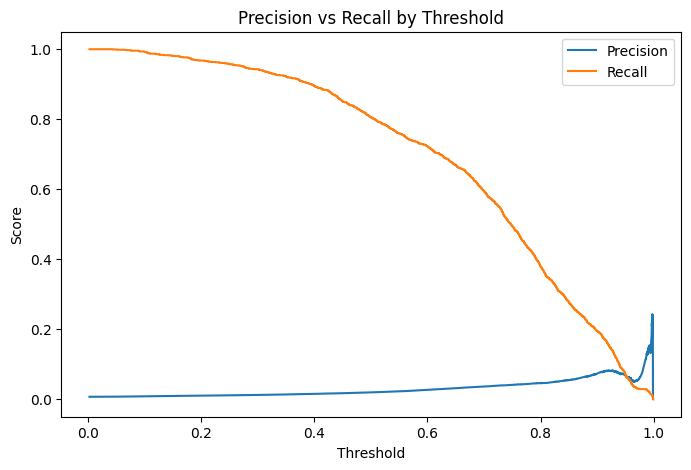

In [19]:
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall by Threshold')
plt.legend()
plt.show()

In [20]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier( n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), eval_metric='logloss', random_state=42 )
xgb_model.fit(X_train, y_train)
print("Done")

Done


In [21]:
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost ROC-AUC: {auc_xgb:.3f}")

              precision    recall  f1-score   support

           0       1.00      0.95      0.98    201510
           1       0.11      0.83      0.20      1420

    accuracy                           0.95    202930
   macro avg       0.56      0.89      0.59    202930
weighted avg       0.99      0.95      0.97    202930

XGBoost ROC-AUC: 0.959


In [24]:
importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols_final).sort_values(ascending=False)
feat_imp.head(15)

,0
StoreTypeStockoutRate,0.257373
CompetitionDistance,0.068063
"PromoInterval_Mar,Jun,Sept,Dec",0.066720
SalesVelocity14,0.051470
"PromoInterval_Jan,Apr,Jul,Oct",0.048420
Promo2SinceWeek,0.046987
Assortment_c,0.046836
Promo,0.046000
CompetitionOpenSinceYear,0.041626
Promo2SinceYear,0.035521


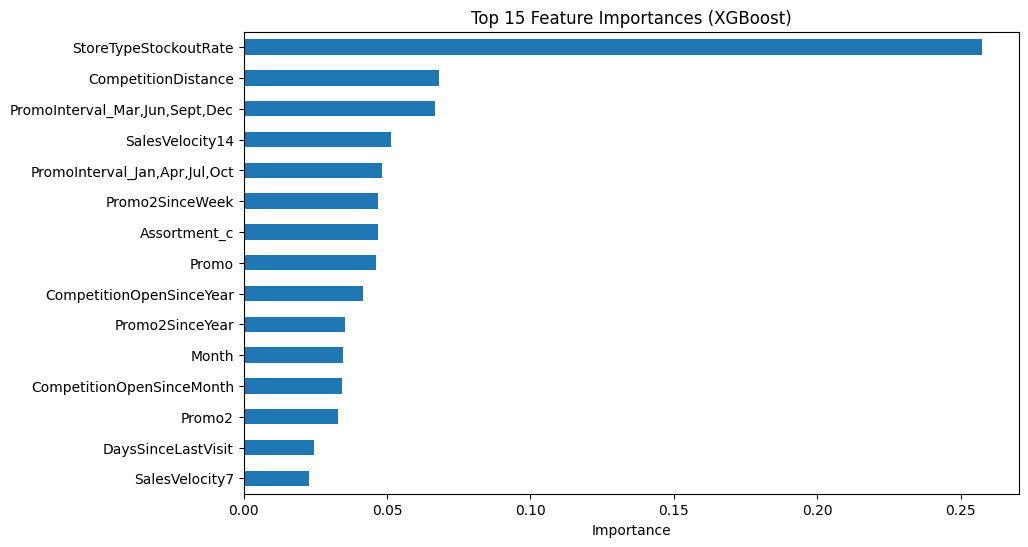

In [23]:
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

In [26]:
xgb_model.save_model('xgb_stockout_model.json')
from google.colab import files
files.download('xgb_stockout_model.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>